In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from modules.LDS import Kalman_EM
from modules.WF_sim import *
from pathlib import Path

# WF simulation

A is not provide! A_demo is used.


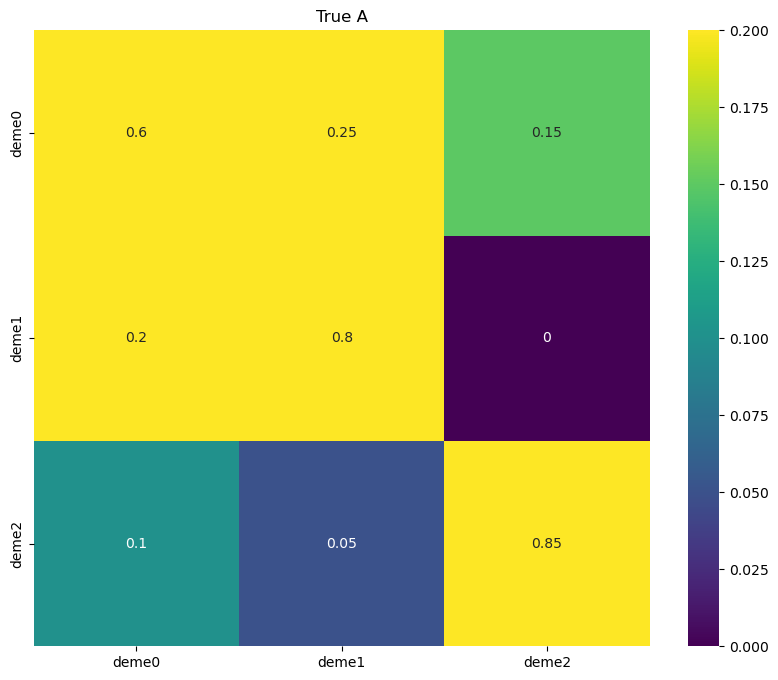

True Neff =  [2000, 2000, 2000]
True measurement noise overdispersion =  [1, 1, 1]


In [2]:
ND = 3 # the number of demes 
T=10 # the number of timepoints
Csn =[1]*ND # strength of measurement noise overdispersion
Npop = [2000]*ND # effective population size
totcounts = np.array([np.random.randint(1000, 3000, ND) for _ in range(T)]).T # number of sequences sampled from each region
A,counts,B=WF_sim(Npop,totcounts, Csn, ND, T, A=None,Ntraj=20)

demes=['deme'+str(i) for i in range(ND)]

plt.figure(figsize=[10,8])
sns.heatmap(A,cmap='viridis',vmax=0.2,annot=True,xticklabels=demes, yticklabels=demes,square=True)
plt.title('True A')
plt.show()

print("True Neff = ", Npop)
print("True measurement noise overdispersion = ", Csn )

## HMM-EM

T= Number of timepoints

NA= Number of alleles

ND = Number of demes

* INPUT
    * counts: spatio-temporal data of allele (or lineage) counts, with shape (ND, NA ,T).
    * totcounts: spatio-temporal data of total number of sampled sequences, with shape (ND, T).
* OUTPUT
    * lnLH_record: Record of log likelihood across EM cycles,
    * A_EM: Inferred A.
    * Ne_EM: Inferred effective population size.
    * A_LS: Least squares solution (noises ignored).
    * Csn_EM: Inferred measurment noise overdispersion.

terminate at step=40, DA=0.00047, ratioDNe=0.02436, ratioDCsn=0.00465


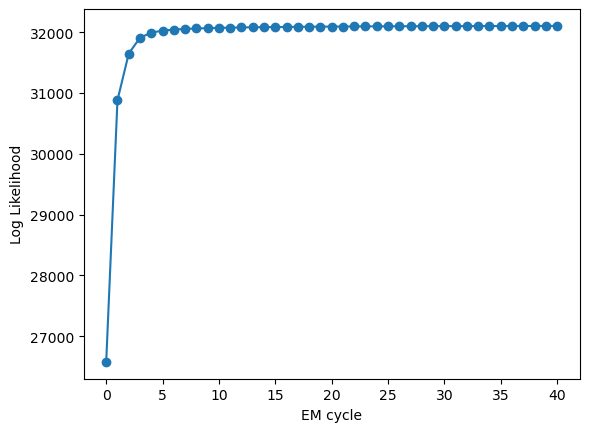

In [9]:
lnLH_record, A_EM, Ne_EM, A_LS,Csn_EM=Kalman_EM(counts=counts+1, 
                                             counts_deme=totcounts, 
                                             em_step_max=100,terminate_th=0.001, 
                                             frac=0.5,noisemode=2,Qprintstep=False)

plt.plot(lnLH_record,marker='o')
plt.xlabel('EM cycle')
plt.ylabel('Log Likelihood')
plt.show()

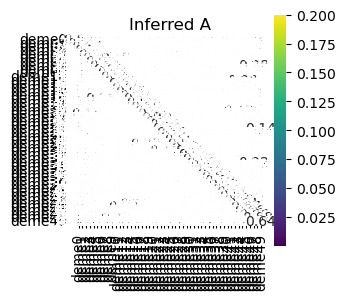

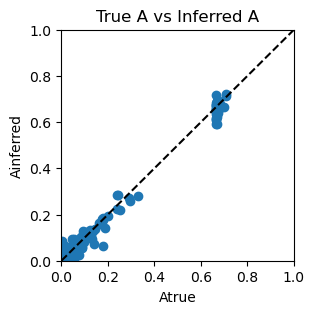

Inferred Neff =  [ 4164.00156492  4630.43988163  3548.33572658  2415.25947115
  5852.59918888  4589.94612731  5418.42491172  2505.75448235
  2169.62362942  3544.03892918  4718.26803469  2417.69696423
  2844.47320875  2814.7070357   4396.07205955  4274.27686887
  3057.18320131  5412.04889224  5257.89292948  6332.18976524
  3588.62530464  2596.02937758  4426.03405381  3128.55146506
  2213.687323    3819.06105846  2878.27257397  3229.55150415
  3046.82548259  2697.69375003  2672.08702482  3803.52967108
  5190.25017362  1995.88909368  2155.07152383  2792.01242101
  4893.82403823 10979.52247006  3886.92754985  2325.88340791
  9289.98295335  2220.42009424  2707.34435845  2796.68767919
  2569.35908278  1761.06905339  5302.57378429  4905.25838179
  3039.32472425  3726.54484983]
Inferred measurement noise overdispersion =  [1.218199  1.1496565 1.2013177 1.4409704 1.3253647 1.4368558 1.3412523
 1.4521226 1.1286298 1.        1.0726616 1.4219154 1.162228  1.0712699
 1.3471812 1.0871768 1.        1

In [11]:
plt.figure(figsize=[3,3])
sns.heatmap(A_EM,cmap='viridis',vmax=0.2,annot=True,xticklabels=demes, yticklabels=demes,square=True)
plt.title('Inferred A')
plt.show()

plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),A_EM.flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

print("Inferred Neff = ", Ne_EM)
print("Inferred measurement noise overdispersion = ", Csn_EM)

# HMM-EM and bootstrapping

In [14]:
# Perform bootstrapping 
def bootstrap_data(counts, size):
    ND, Ntraj, T = counts.shape
    return np.array([counts[:,np.random.choice(list(range(Ntraj)),size = Ntraj,replace = True),:] for _ in range(size)])

bootstrap_counts = bootstrap_data(counts, size=10) # only 10 bootstrapped datasets are generated for demonstration purposes.


## Compute in this notebook 

In [17]:

res_A_EM=[]
for BS_counts in bootstrap_counts:
    lnLH_record, A_EM, Ne_EM, A_LS,Csn_EM=Kalman_EM(counts=BS_counts+1, 
                                                counts_deme=totcounts, 
                                                em_step_max=100,terminate_th=0.001, 
                                                frac=0.5,noisemode=2,Qprintstep=False)
    
    res_A_EM.append(A_EM)
res_A_EM=np.array(res_A_EM)


A_EM_mean = np.mean(res_A_EM,axis=0)
A_EM_std  = np.std(res_A_EM,axis=0)

A_EM_mean, A_EM_std 


terminate at step=80, DA=0.00079, ratioDNe=0.02424, ratioDCsn=0.00317
terminate at step=82, DA=0.001, ratioDNe=0.01688, ratioDCsn=0.00235
terminate at step=62, DA=0.00098, ratioDNe=0.02289, ratioDCsn=0.00306
terminate at step=51, DA=0.00059, ratioDNe=0.02489, ratioDCsn=0.00349
terminate at step=43, DA=0.00083, ratioDNe=0.02493, ratioDCsn=0.00451
terminate at step=51, DA=0.00069, ratioDNe=0.02497, ratioDCsn=0.00348
terminate at step=48, DA=0.00091, ratioDNe=0.02458, ratioDCsn=0.00401
terminate at step=51, DA=0.00095, ratioDNe=0.02418, ratioDCsn=0.00471
terminate at step=65, DA=0.00097, ratioDNe=0.02116, ratioDCsn=0.00358
terminate at step=56, DA=0.001, ratioDNe=0.02394, ratioDCsn=0.00548


(array([[5.78860780e-01, 6.72997635e-06, 7.53338121e-03, ...,
         4.03048908e-06, 1.40163730e-02, 2.95941523e-06],
        [1.44265953e-03, 6.74772922e-01, 2.76270277e-05, ...,
         6.29958973e-06, 7.92163678e-04, 2.56290561e-04],
        [7.20149226e-06, 1.86466675e-02, 6.28980377e-01, ...,
         2.25476512e-02, 9.28938116e-02, 3.66545799e-03],
        ...,
        [4.47707304e-03, 1.07039346e-05, 9.52949209e-03, ...,
         6.65621601e-01, 2.93265500e-02, 1.81814329e-04],
        [1.61112065e-06, 2.00968649e-06, 6.42640278e-03, ...,
         1.72525994e-06, 6.72597231e-01, 3.27346192e-03],
        [3.40364390e-06, 3.39347022e-02, 6.55580039e-03, ...,
         2.01637396e-02, 3.11158388e-02, 6.11122866e-01]]),
 array([[4.68011984e-02, 9.27196526e-06, 1.49899496e-02, ...,
         4.80656524e-06, 1.21520624e-02, 2.60147550e-06],
        [4.23455546e-03, 2.04215309e-02, 6.01991449e-05, ...,
         8.40525093e-06, 2.33378478e-03, 5.98792335e-04],
        [1.62561643e-05, 

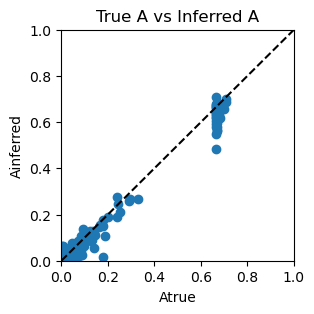

In [19]:
plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),A_EM_mean.flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

## Execute from command line

In [58]:
# Export input data
filename= 'WFsim'
np.save('HMM_EM/input/counts_'+filename+'.npy',bootstrap_counts)
np.save('HMM_EM/input/totcounts_'+filename+'.npy',totcounts)


In [59]:
import os
import subprocess

subprocess.run(["python","HMMEM.py", "WFsim"])  # May raise an error


filename: WFsim
noisemode: 2
ridge: 0.0
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
terminate at step=16, DA=9e-05, ratioDNe=0.01237, ratioDCsn=0.00495
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
terminate at step=18, DA=0.0001, ratioDNe=0.00785, ratioDCsn=0.00427
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
step 23
step 24
step 25
step 26
step 27
step 28
step 29
step 30
step 31
step 32
step 33
step 34
step 35
step 36
terminate at step=36, DA=0.0001, ratioDNe=0.00813, ratioDCsn=0.00244
step 0
step 1
step 2
step 3
step 4
step 5
step 6
step 7
step 8
step 9
step 10
step 11
step 12
step 13
step 14
step 15
step 16
step 17
step 18
step 19
step 20
step 21
step 22
terminate at step=22, DA=0

CompletedProcess(args=['python', 'HMMEM.py', 'WFsim'], returncode=0)

In [60]:
res_A_EM=np.load("HMM_EM/output/A_ridge0.0_"+filename+".npy")
res_Ne_EM=np.load("HMM_EM/output/Ne_ridge0.0_"+filename+".npy")
res_Csn_EM=np.load("HMM_EM/output/Csn_ridge0.0_"+filename+".npy")

A_EM_mean = np.mean(res_A_EM,axis=0)
A_EM_std  = np.std(res_A_EM,axis=0)

A_EM_mean, A_EM_std 

(array([[5.47471228e-01, 2.84975016e-01, 1.67553756e-01],
        [1.93801458e-01, 8.05456272e-01, 7.42270628e-04],
        [1.06722312e-01, 6.29104280e-02, 8.30367260e-01]]),
 array([[0.01951604, 0.01134944, 0.01412968],
        [0.01778059, 0.01758707, 0.00143003],
        [0.03392765, 0.02302089, 0.01700497]]))

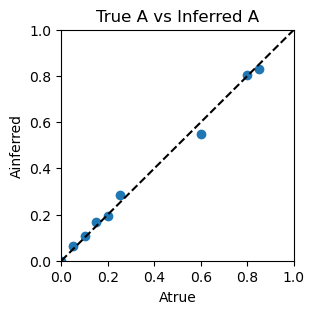

In [61]:
plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),A_EM_mean.flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

## HMM-MCMC (C++)

T= Number of timepoints

NA= Number of alleles

ND = Number of demes

* INPUT
    * counts: spatio-temporal data of allele (or lineage) counts. CSV file with shape (TxNA, ND). The frequencies of the i-th lineage at time t appears at the (i-1)*T + t -th row.
    * totcounts: spatio-temporal data of total number of sampled sequences. CSV file with shape (T, ND).
* OUTPUT
    * A_MCMC: Posterior distribution of A.
    * Ne_MCMC: Posterior distribution of effective population size.
    * Csn_MCMC: Posterior distribution of measurment noise overdispersion.
from modules.HMMtools import *

In [16]:
dir_IO ='demo'
filename='WFsim'

In [17]:
MCMC_dir = 'HMM_MCMC/'

inpath=MCMC_dir+'input/'#+dir_IO+'/'
Path(inpath).mkdir(parents=True, exist_ok=True)

ND,Nmut,tmax  = counts.shape

counts_  = counts.transpose()
shapelst=list(counts_.shape)

aux=np.vstack([counts_[:, i, :] for i in range(Nmut)])

np.savetxt(inpath+'counts_'+filename+'.csv', aux, fmt="%d", delimiter=",")
np.savetxt(inpath+'totcounts_'+filename+'.csv', totcounts.transpose(), fmt="%d", delimiter=",")
np.savetxt(inpath+'shape_'+filename+'.csv', shapelst, fmt="%d", delimiter=",") #  shapelist = #timepoints, #trajectories, #demes
    

In [18]:
import os
import subprocess
try:
    os.chdir("HMM_MCMC/")
    subprocess.run(["./NI_MCMC", "-f", "WFsim","-m", "100", "-n","2"])  # May raise an error
finally:
    os.chdir('..')



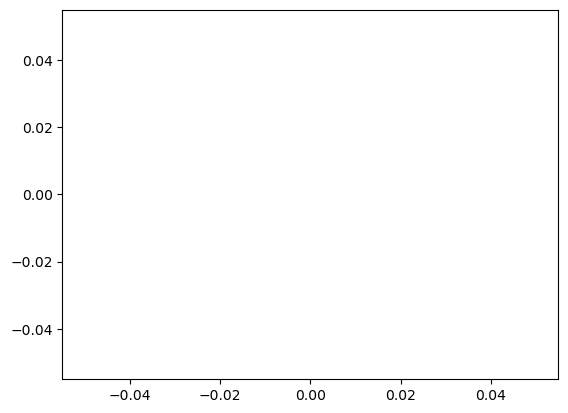

In [19]:
A_mcmc=np.loadtxt(MCMC_dir+'output/A_'+filename+'.csv',delimiter=',')
Ne_mcmc=np.loadtxt(MCMC_dir+'output/Ne_'+filename+'.csv',delimiter=',')
C_mcmc=np.loadtxt(MCMC_dir+'output/C_'+filename+'.csv',delimiter=',')
# Use genfromtxt to handle '-nan(ind)' as np.nan
logLH_mcmc = np.genfromtxt(MCMC_dir+'output/logLH_'+filename+'.csv', delimiter=',', dtype=float, missing_values='-nan(ind)', filling_values=np.nan)

A_mcmc=np.array([ i.reshape((Ne_mcmc.shape[1],Ne_mcmc.shape[1])) for i in A_mcmc])

plt.plot(logLH_mcmc[:,0],logLH_mcmc[:,1])
plt.show()

In [21]:
# Diagnostics: Check for NaNs and shapes after burn-in
print('A_mcmc shape:', A_mcmc.shape, 'NaNs:', np.isnan(A_mcmc).sum())
print('Ne_mcmc shape:', Ne_mcmc.shape, 'NaNs:', np.isnan(Ne_mcmc).sum())
print('C_mcmc shape:', C_mcmc.shape, 'NaNs:', np.isnan(C_mcmc).sum())
if 'logLH_mcmc' in locals():
    print('logLH_mcmc shape:', logLH_mcmc.shape, 'NaNs:', np.isnan(logLH_mcmc).sum())
    print('First 10 logLH_mcmc:', logLH_mcmc[:10])

A_mcmc shape: (100, 3, 3) NaNs: 0
Ne_mcmc shape: (100, 3) NaNs: 0
C_mcmc shape: (100, 3) NaNs: 0
logLH_mcmc shape: (100, 2) NaNs: 100
First 10 logLH_mcmc: [[ 0. nan]
 [ 1. nan]
 [ 2. nan]
 [ 3. nan]
 [ 4. nan]
 [ 5. nan]
 [ 6. nan]
 [ 7. nan]
 [ 8. nan]
 [ 9. nan]]


In [270]:
# Burn-in
burn_in=int(0.5*len(A_mcmc))
A_mcmc = A_mcmc[burn_in:]
Ne_mcmc= Ne_mcmc[burn_in:]
C_mcmc = C_mcmc[burn_in:]


In [15]:
# Print the A_mcmc array after burn-in
print('A_mcmc array after burn-in:')
print(A_mcmc)

A_mcmc array after burn-in:
[[[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  [0.258029  0.657256  0.0847152]
  [0.160997  0.0847152 0.754288 ]]

 [[0.580974  0.258029  0.160997 ]
  

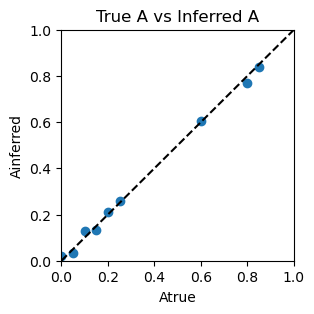

Inferred Neff =  [1827.321278 1485.65646  1727.911692]
Inferred measurement noise overdispersion =  [1.29273413 1.18138973 1.17137445]


In [271]:

plt.figure(figsize=(3,3))
plt.scatter(A.flatten(),np.mean(A_mcmc,axis=0).flatten())
plt.plot([0,1],'--',color='k')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Atrue')
plt.ylabel('Ainferred')
plt.title('True A vs Inferred A')
plt.show()

print("Inferred Neff = ", np.mean(Ne_mcmc,axis=0))
print("Inferred measurement noise overdispersion = ", np.mean(C_mcmc,axis=0))

## Non-negative Matrix Factorization (NMF) Analysis

Non-negative Matrix Factorization (NMF) is a dimensionality reduction technique that decomposes a non-negative matrix (such as the inferred transition matrix $A_{ij}$) into two lower-rank non-negative matrices. This allows us to identify latent features or modules within the transition matrix, providing insight into the underlying structure of migration or interaction rates between demes. Here, we apply NMF to the mean inferred $A_{ij}$ from bootstrapping to visualize and interpret its latent components.

* **INPUT**
    * `A_EM_mean`: Mean inferred transition matrix $A_{ij}$ from bootstrapping (shape: ND x ND).
    * `n_components`: Number of latent components to extract (user-defined).
* **OUTPUT**
    * `W`: NMF basis matrix (shape: ND x n_components).
    * `H`: NMF coefficient matrix (shape: n_components x ND).
    * Visualizations of the basis and coefficient matrices.

In [2]:
import numpy as np
# Load England Delta data for 9-deme and 50-deme cases (NPY format) with correct paths
npy_9_path = r'data/England_Delta_9_MCMC/output/A_England_Delta_9.npy'  # Update if your 9-deme file has a different name
npy_50_path = r'data/England_Delta_50_EM/output/A_England_Delta.npy'

try:
    data_9 = np.load(npy_9_path)
    print('9-deme data shape:', data_9.shape)
except Exception as e:
    print(f'Could not load 9-deme npy file: {e}')
    data_9 = None
data_50 = np.load(npy_50_path)
print('50-deme data shape:', data_50.shape)


# Flatten the 9-deme and 50-deme data arrays
if data_9 is not None:
    data_9_flat = data_9.reshape(data_9.shape[0], -1)
    print('9-deme flattened shape:', data_9_flat.shape)  # Should be (5000, 81)
else:
    data_9_flat = None
data_50_flat = data_50.reshape(data_50.shape[0], -1)
print('50-deme flattened shape:', data_50_flat.shape)  # Should be (100, 2500)

9-deme data shape: (5000, 9, 9)
50-deme data shape: (100, 50, 50)
9-deme flattened shape: (5000, 81)
50-deme flattened shape: (100, 2500)


c:\Users\garva\Anaconda\envs\NetworkInfer\Lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NMF ANALYSIS: 5000 samples, 9×9 demes, 3 components


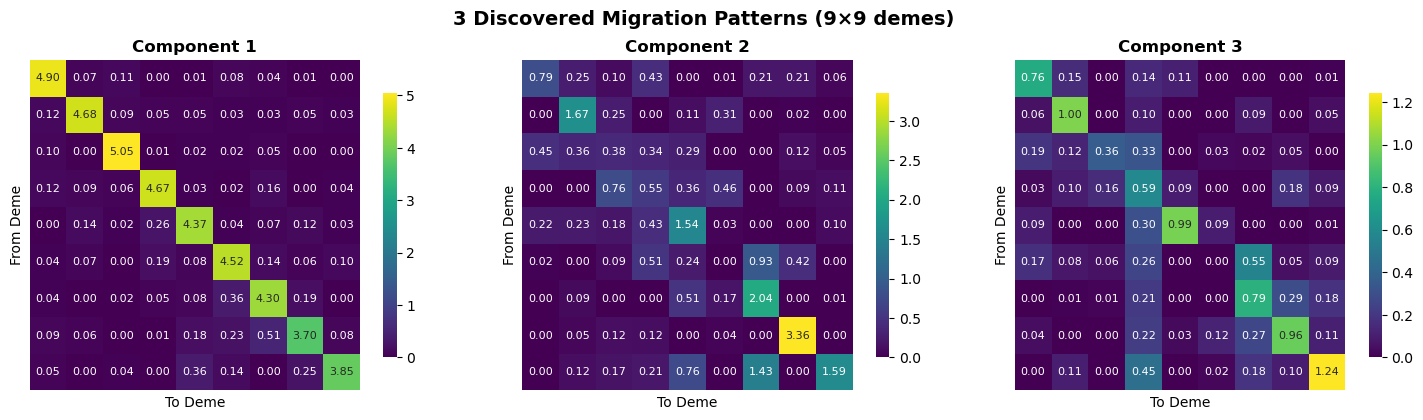

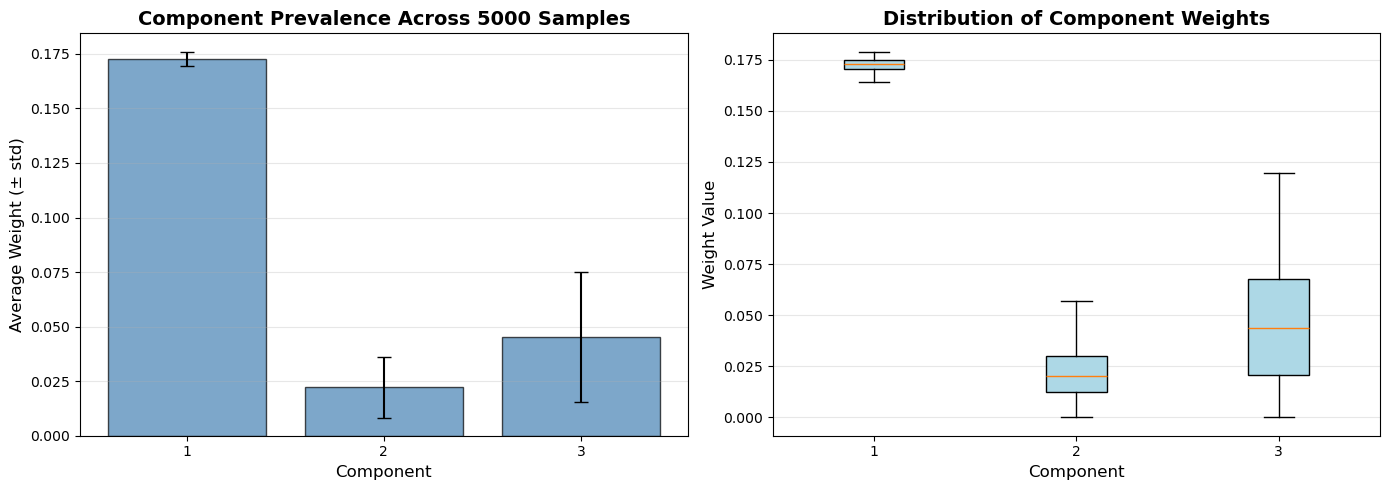


COMPONENT STATISTICS:
--------------------------------------------------------------------------------
Comp   Mean       Std        Min        Max        %NonZero   Pattern Sparsity
--------------------------------------------------------------------------------
1      0.1726     0.0030     0.1642     0.1790     100.0      12.3           %
2      0.0222     0.0140     0.0000     0.0568     95.3       32.1           %
3      0.0451     0.0298     0.0000     0.1195     91.2       25.9           %


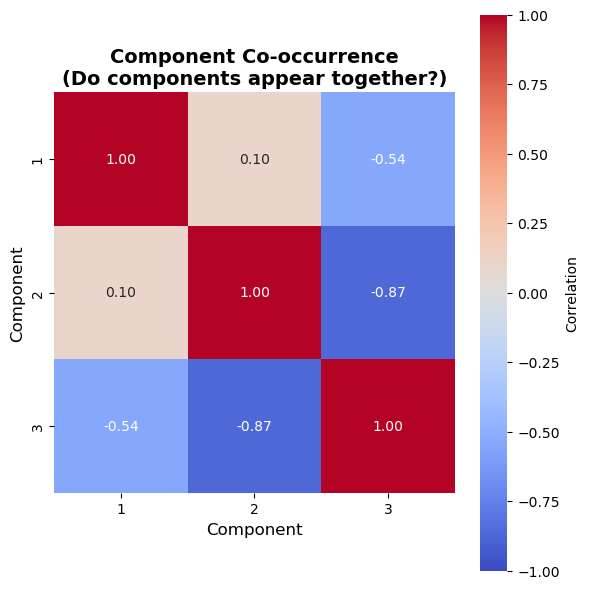

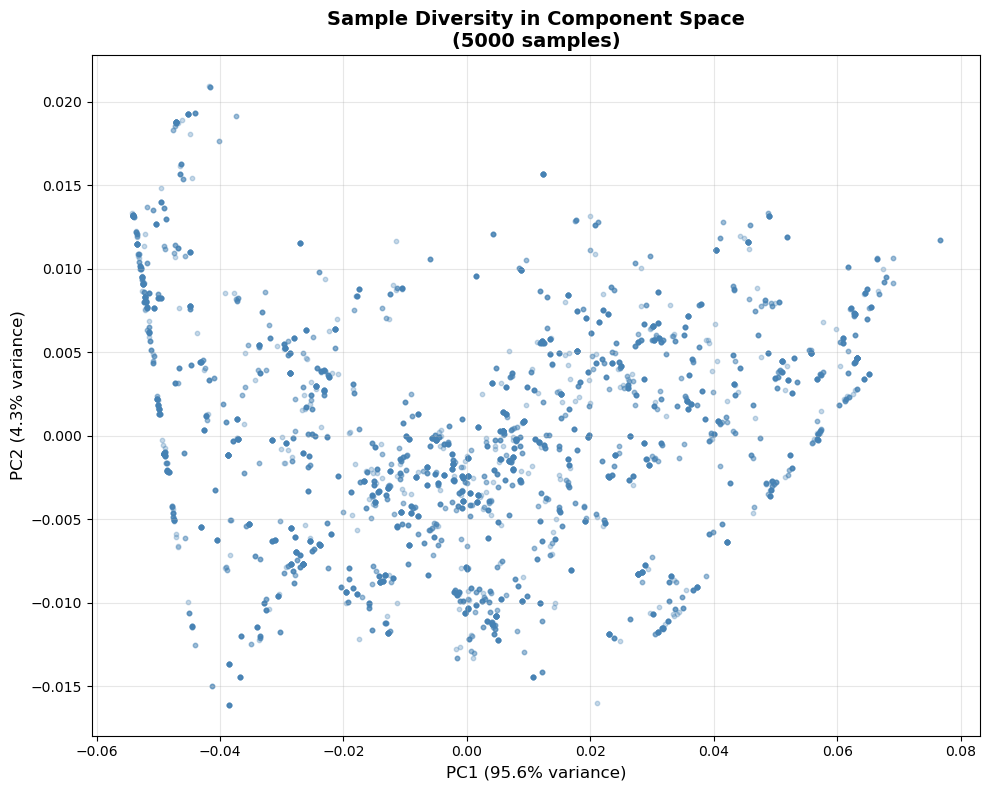



EXAMPLE SAMPLE COMPOSITIONS:
--------------------------------------------------------------------------------

Sample 0:
  Component 1: 0.1741 ████████
  Component 2: 0.0175 
  Component 3: 0.0475 ██

Sample 1249:
  Component 1: 0.1663 ████████
  Component 2: 0.0024 
  Component 3: 0.1048 █████

Sample 2499:
  Component 1: 0.1729 ████████
  Component 2: 0.0204 █
  Component 3: 0.0508 ██

Sample 3749:
  Component 1: 0.1719 ████████
  Component 2: 0.0146 
  Component 3: 0.0631 ███

Sample 4999:
  Component 1: 0.1715 ████████
  Component 2: 0.0398 █
  Component 3: 0.0158 

Analysis complete! Figures saved with prefix: nmf_analysis
NMF summary: {'n_samples': 5000, 'n_demes': 9, 'n_components': 3, 'prevalence': array([0.17259783, 0.02222268, 0.04512917]), 'std': array([0.00303273, 0.01395901, 0.02982505]), 'correlation': array([[ 1.        ,  0.09858158, -0.54107819],
       [ 0.09858158,  1.        , -0.86887192],
       [-0.54107819, -0.86887192,  1.        ]])}


In [13]:
# NMF analysis using your pipeline: fit NMF, then analyze results
from modules.nmf_analysis import apply_nmf_to_Aij, analyze_nmf_results

# Choose which data to analyze: data_9_flat or data_50_flat
X = data_9_flat  # or data_50_flat for 50-deme
n_components = 3  # Set as needed

# Fit NMF
W, H, nmf_model = apply_nmf_to_Aij(X, n_components=n_components)

# Analyze NMF results using your custom function
nmf_summary = analyze_nmf_results(W, H)

# nmf_summary contains prevalence, std, correlation, etc.
print('NMF summary:', nmf_summary)

In [29]:
print("NMF components shape (W):", W.shape)
print(W)


NMF components shape (W): (5000, 7)
[[0.16487184 0.00227411 0.00293087 ... 0.03784613 0.00414019 0.06896916]
 [0.16145051 0.00289412 0.00512738 ... 0.04513614 0.         0.06155643]
 [0.16145051 0.00289412 0.00512738 ... 0.04513614 0.         0.06155643]
 ...
 [0.15977259 0.03694035 0.0075864  ... 0.02011484 0.01656664 0.        ]
 [0.15977259 0.03694035 0.0075864  ... 0.02011484 0.01656664 0.        ]
 [0.15977259 0.03694035 0.0075864  ... 0.02011484 0.01656664 0.        ]]


In [9]:
# Call your NMF results analysis function from nmf_analysis.py
from modules.nmf_analysis import analyze_nmf_results


# Run NMF and analyze results using your custom function
nmf_result = analyze_nmf_results(W, H)

# If your function returns plots or summary, it will be displayed automatically. If it returns data, you can print or further process it:
print(nmf_result)

ImportError: cannot import name 'analyze_nmf_results' from 'modules.nmf_analysis' (c:\Users\garva\Documents\Research\Hallatschek\NetworkInfer\modules\nmf_analysis.py)